# Clasificación de Imágenes con Redes Neuronales Preentrenadas (ResNet18)

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de esta sesión es familiarizarnos con el uso de **modelos preentrenados** de visión artificial profunda. Cargaremos y utilizaremos la arquitectura de referencia **ResNet18** (entrenada en ImageNet) dentro del ecosistema de PyTorch para realizar clasificación de imágenes del mundo real sin necesidad de entrenar un modelo desde cero.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Explicar el concepto y las ventajas del uso de modelos preentrenados en Procesamiento Digital de Imágenes.
2. Cargar y configurar la arquitectura residual `ResNet18` en PyTorch empleando pesos preentrenados oficiales de `torchvision`.
3. Diseñar y aplicar el pipeline de preprocesamiento de tensores (redimensionado, recorte central, conversión a tensores y normalización estándar) requerido por los modelos de ImageNet.
4. Ejecutar flujos de inferencia libre de cálculo de gradientes y decodificar las predicciones top-5 más altas de un clasificador generalista.

## Terminología clave (Microglosario)

*   **Modelo Preentrenado:** Red neuronal cuyos pesos ya han sido optimizados en un conjunto de datos masivo. Esto nos permite aprovechar sus filtros jerárquicos de detección de formas, bordes y texturas sin gastar tiempo en un entrenamiento desde cero. *Como contratar a un médico especialista con diez años de experiencia: el conocimiento base ya está incorporado y no necesitamos formarlo desde la escuela primaria.*
*   **ResNet18 (Red Residual):** Arquitectura de red neuronal convolucional caracterizada por poseer conexiones residuales (*shortcut connections*), las cuales mitigan el problema de desvanecimiento del gradiente al permitir que la información saltee ciertas capas. *Como un edificio con escaleras de emergencia que permiten saltear pisos: la información puede tomar atajos cuando las capas intermedias no aportan nada útil.*
*   **ImageNet:** Dataset de referencia estándar en visión artificial que cuenta con más de 14 millones de imágenes clasificadas de forma manual en 1000 categorías de objetos comunes. *Como la enciclopedia visual más grande del mundo: si un modelo aprendió de ImageNet, reconoce casi cualquier objeto cotidiano que aparezca en una fotografía.*
*   **Normalización Espacial:** Ajuste numérico aplicado a los píxeles de una imagen para que su media y desviación estándar coincidan con las estadísticas del conjunto de entrenamiento original de ImageNet, garantizando la consistencia del modelo. *Como calibrar una balanza con un peso de referencia antes de pesar algo: el modelo necesita que la imagen llegue en el "idioma numérico" con el que aprendió.*

## 1. Configuración de Librerías y Dependencias

Carguemos las herramientas esenciales de PyTorch, torchvision, solicitudes de red y visualización gráfica.

In [1]:
print('✦ Instalando dependencias en el sistema...')
%pip install -q torch torchvision matplotlib requests pillow
print('✓ Librerías instaladas con éxito.')

✦ Instalando dependencias en el sistema...
Note: you may need to restart the kernel to use updated packages.
✓ Librerías instaladas con éxito.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
print('✦ Cargando librerías y configurando entorno de Deep Learning...')
import torch
from torchvision import models, transforms
from PIL import Image
import requests
import matplotlib.pyplot as plt
print('✓ Entorno listo para operar.\n')

print('✦ Descargando y cargando ResNet18 preentrenado con ImageNet...')
# Cargamos el modelo utilizando la constante oficial de pesos por defecto
modelo = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Configuramos el modelo en modo de evaluación (desactiva capas de dropout y batch normalization)
modelo.eval()
print('✓ Modelo cargado correctamente en modo de evaluación.')

✦ Cargando librerías y configurando entorno de Deep Learning...
✓ Entorno listo para operar.

✦ Descargando y cargando ResNet18 preentrenado con ImageNet...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Robert/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


✓ Modelo cargado correctamente en modo de evaluación.


## ✦ Antes de codificar: el pipeline de preprocesamiento paso a paso

Antes de ejecutar el código, vamos a recorrer manualmente qué hace cada transformación con una imagen hipotética de $800 \times 500$ píxeles:

| Paso | Transformación | Qué ocurre | Resultado |
|---|---|---|---|
| 1 | `Resize(256)` | El lado más corto (500 px) se escala a 256 px. El otro se reduce proporcionalmente: $800 \times 256/500 \approx 410$ px | **410 × 256 px** |
| 2 | `CenterCrop(224)` | Se recorta el cuadrado central exacto de 224×224 px | **224 × 224 px** |
| 3 | `ToTensor()` | Los píxeles (enteros 0–255) se convierten a decimales en el rango [0, 1] | **Tensor de forma (3, 224, 224)** |
| 4 | `Normalize(...)` | Cada canal se centra y escala con la media y desviación estándar de ImageNet | **Tensor normalizado** |

Este pipeline no es arbitrario: es exactamente el formato con el que ResNet18 fue entrenada en ImageNet. Pasarle una imagen en otro formato sería como hablarle en otro idioma.

## 2. Definición del Pipeline de Preprocesamiento

Para que la red ResNet18 procese la imagen correctamente, debemos adecuar sus dimensiones y estadísticas numéricas al mismo formato con el que fue entrenada originalmente en ImageNet ($224 \times 224$ píxeles con normalización estándar de canal).

In [3]:
# Definimos el pipeline de transformaciones secuenciales en PyTorch
preprocesado = transforms.Compose([
    # Redimensionamos la imagen de forma que el lado menor mida 256 píxeles
    transforms.Resize(256),
    # Recortamos una sección cuadrada de 224x224 en el centro de la imagen
    transforms.CenterCrop(224),
    # Convertimos la imagen de formato PIL a un tensor de PyTorch, escalando los valores al rango [0, 1]
    transforms.ToTensor(),
    # Normalizamos el tensor utilizando la media y desviación estándar exactas de ImageNet
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 3. Descarga y Visualización de la Imagen de Prueba

Descargaremos una imagen real de internet para testear nuestro clasificador y aplicaremos las transformaciones de preprocesamiento.

✦ Descargando imagen de prueba desde internet...
✓ Imagen obtenida con éxito.



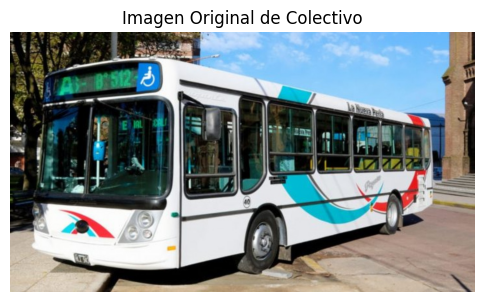

✓ Imagen preprocesada y convertida a tensor compatible.


In [4]:
# Imagen de calzado para correr en internet
url_imagen = 'https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.madariaga.gob.ar%2Ffotos%2Fmadariaga%2Fnoticias%2Fcolectivo4.jpg&f=1&nofb=1&ipt=e52e0e0c12da53e41cc7d59463213061afc963dbfa26b92f59ded23345d778d3'

try:
    print('✦ Descargando imagen de prueba desde internet...')
    respuesta = requests.get(url_imagen, stream=True, timeout=15)
    imagen = Image.open(respuesta.raw)
    print('✓ Imagen obtenida con éxito.\n')
    
    # Visualizamos la imagen original utilizando matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen)
    plt.title('Imagen Original de Colectivo')
    plt.axis('off')
    plt.show()
    
    # Preprocesamos y añadimos la dimensión de lote (batch dimension) necesaria para PyTorch (1, C, H, W)
    input_tensor = preprocesado(imagen).unsqueeze(0)
    print('✓ Imagen preprocesada y convertida a tensor compatible.')
except Exception as e:
    print(f'✗ Error al descargar o preprocesar la imagen: {e}')

## 4. Inferencia y Clasificación en ImageNet

Descargaremos el mapeo oficial de las 1000 categorías de ImageNet, pasaremos la imagen por la red ResNet18 y decodificaremos las 5 categorías más probables asignadas por el modelo.

In [5]:
# URL del archivo de etiquetas oficiales de ImageNet en PyTorch Hub
url_etiquetas = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'

try:
    print('✦ Descargando etiquetas oficiales de ImageNet...')
    respuesta_etiquetas = requests.get(url_etiquetas, timeout=15)
    etiquetas = respuesta_etiquetas.text.split('\n')
    print(f'✓ {len(etiquetas)} categorías listas para clasificar.\n')

    print('✦ Ejecutando inferencia con la red ResNet18...')
    # Desactivamos el cálculo de gradientes para ahorrar memoria y tiempo
    with torch.no_grad():
        salida = modelo(input_tensor)
    # Aplicamos Softmax sobre la salida de 1000 elementos para obtener probabilidades relativas
    probabilidades = torch.nn.functional.softmax(salida[0], dim=0)
    
    # Extraemos las 5 probabilidades más altas y sus respectivos índices
    valores_top, indices_top = torch.topk(probabilidades, 5)
    
    print('Resultados de Clasificación del Modelo (Top 5):')
    for i in range(5):
        nombre_clase = etiquetas[indices_top[i]]
        porcentaje = valores_top[i].item() * 100
        print(f'  ❖ {i+1}. {nombre_clase}: {porcentaje:.2f}%')

except Exception as e:
    print(f'✗ Error durante la inferencia o decodificación: {e}')

✦ Descargando etiquetas oficiales de ImageNet...
✓ 1000 categorías listas para clasificar.

✦ Ejecutando inferencia con la red ResNet18...
Resultados de Clasificación del Modelo (Top 5):
  ❖ 1. trolleybus: 72.27%
  ❖ 2. minibus: 15.98%
  ❖ 3. streetcar: 10.59%
  ❖ 4. passenger car: 0.77%
  ❖ 5. recreational vehicle: 0.34%


## Consigna de Lectura e Interpretación

Revisen los resultados impresos de las predicciones del modelo. ¿Cuál fue el objeto con mayor porcentaje de probabilidad asignado por la red? El objet con mayor porcentaje fue el trolleybus (72.27%)
 Compárenlo con el colectivo que se observa en la imagen original de prueba. Dentro de las etiquetas posibles, es lo más similar visualmente.

  ¿Qué ventajas identifican en utilizar un modelo que ya posee este conocimiento preentrenado?
  Al usar un modelo preentrenado, nos permite ahorrar tiempo y recursos ya que el modelo tuvo un entrenamiento previo. Asimismo, podemos adaptar el modelo a las tareas específicas deseadas.



## Cierre de Laboratorio

Comprobaron de forma práctica la potencia y simplicidad que brinda utilizar un modelo del estado del arte preentrenado de visión artificial como **ResNet18**.

En la siguiente sesión daremos un paso sumamente importante: utilizaremos la técnica de **Transferencia de Aprendizaje (Transfer Learning)** para congelar este conocimiento base y re-entrenar las capas finales en un conjunto de imágenes personalizado.